#### imports

In [ ]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.applications import MobileNetV2
from keras import layers
from tensorflow import data as tf_data
import os
import random
import zipfile
import shutil
import pandas as pd
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay,classification_report)
import reload_data2
from google.colab import drive
#drive.mount('/content/drive')

ModuleNotFoundError: No module named 'reload_data2'

# HighRes (442,442)

## Data Loading

In [ ]:
data_dir = "/content/Data"
os.mkdir(data_dir)

In [ ]:
! unzip -d /content/Data /content/drive/MyDrive/CSAFE_zips/Handwriting_Images_90sorted.zip

In [ ]:
shutil.rmtree("/content/Data/__MACOSX")

In [ ]:
data_dir = "/content/Data/Handwriting_Images"

In [ ]:
IMAGE_SIZE = (442,442)
BATCH_SIZE = 64
INPUT_SHAPE = IMAGE_SIZE + (3,)
NUM_CLASSES = 90

In [ ]:
reload_data2.stratify_split_alt(data_dir)
train_ds,val_ds,test_ds=reload_data2.train_val_test_split(data_dir,
                                                       IMAGE_SIZE=IMAGE_SIZE,
                                                       BATCH_SIZE=BATCH_SIZE)

Found 1350 files belonging to 90 classes.
Found 540 files belonging to 90 classes.
Found 540 files belonging to 90 classes.


## Modelling

In [ ]:
def make_transfer_model(input_shape, num_classes, name):
    backbone = base_model

    backbone.trainable = False

    inputs = layers.Input(input_shape)
    x = keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = backbone(x)
    x = layers.Dropout(0.3)(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.25)(x) #changed to 30% dropout
    outputs = layers.Dense(num_classes, activation=None)(x)

    return keras.Model(inputs, outputs, name=name)

base_model = keras.applications.MobileNetV2(
                        include_top = False,
                        classifier_activation="softmax",
                        weights = "imagenet",
                        input_shape=(IMAGE_SIZE + (3,))
                        )

model = make_transfer_model(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES,
                            name="mobilenet_highres2")

/tmp/ipykernel_1176/3788383598.py:18: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


In [ ]:
model.summary()

Model: "mobilenet_highres2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 442, 442, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 442, 442, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 442, 442, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 14, 14, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 1280)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 90)             │       115,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,373,274 (9.05 MB)

 Trainable params: 115,290 (450.35 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### epochs

In [ ]:
%%time

epochs = 100

model.compile(
    optimizer= "adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc"),
             keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc")],
    )

history = model.fit(
    train_ds,
    epochs= epochs,
    validation_data= val_ds)

model.save("MobileNetV2_highres2.keras")

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - acc: 0.0192 - loss: 4.9501 - top3_acc: 0.0467 - val_acc: 0.0259 - val_loss: 4.3935 - val_top3_acc: 0.0741
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 275ms/step - acc: 0.0337 - loss: 4.4469 - top3_acc: 0.1010 - val_acc: 0.1111 - val_loss: 4.1271 - val_top3_acc: 0.2278
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 290ms/step - acc: 0.0864 - loss: 4.1770 - top3_acc: 0.1822 - val_acc: 0.1444 - val_loss: 3.9467 - val_top3_acc: 0.2944
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 275ms/step - acc: 0.1135 - loss: 3.9227 - top3_acc: 0.2365 - val_acc: 0.2315 - val_loss: 3.7745 - val_top3_acc: 0.3852
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 287ms/step - acc: 0.1654 - loss: 3.7476 - top3_acc: 0.3111 - val_acc: 0.2759 - val_loss: 3.6338 - val_top3_acc: 0.4556
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 276ms/step - acc: 0.1866 - loss: 3.6110 - top3_acc: 0.3354 - val_acc: 0.3037 - val_loss: 3.4956 - val_top3_acc: 0.4907
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━

In [ ]:
#save metrics
lossacc = pd.DataFrame(history.history)
lossacc.to_csv("highres2_lossacc.csv")

### Visualization

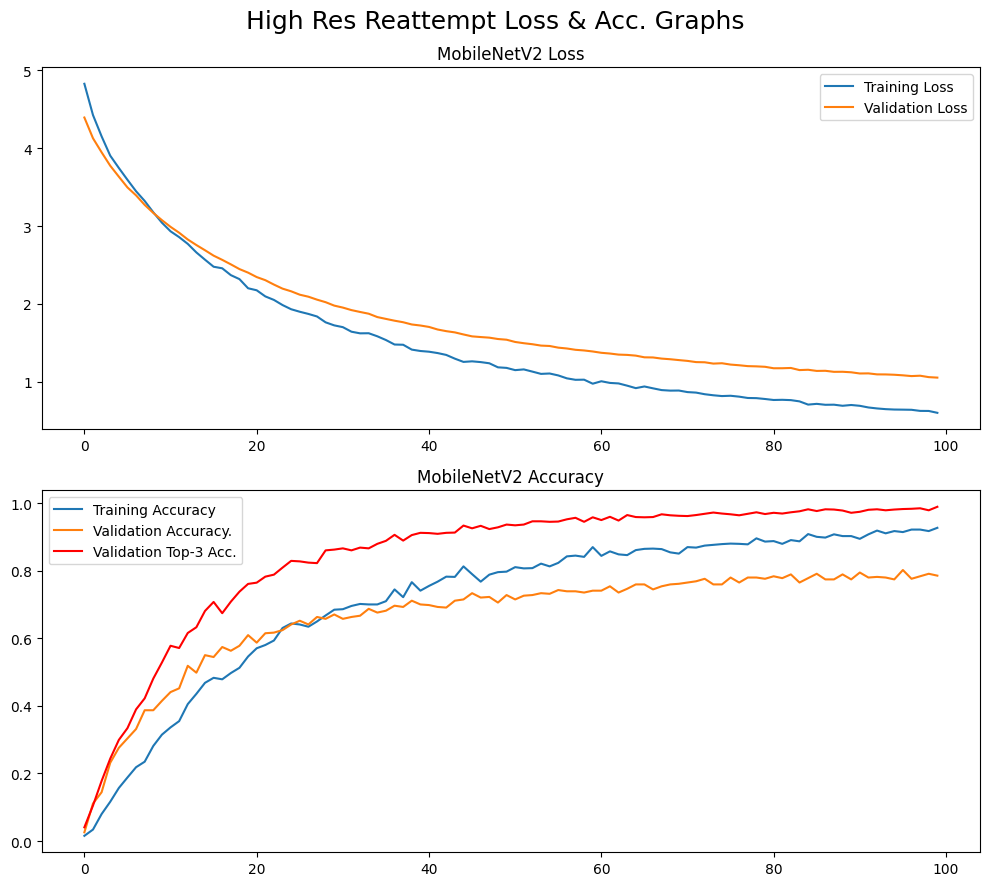

In [ ]:
plt.figure(figsize=(10,9))
plt.suptitle("High Res Reattempt Loss & Acc. Graphs",size=18)

plt.subplot(2,1,1)
plt.plot(range(len(history.history["loss"])),history.history["loss"],label="Training Loss")
plt.plot(range(len(history.history["val_loss"])),history.history["val_loss"],label="Validation Loss")
plt.title("MobileNetV2 Loss")
plt.legend()

plt.subplot(2,1,2)
plt.plot(range(len(history.history["acc"])),history.history["acc"],label="Training Accuracy")
plt.plot(range(len(history.history["val_acc"])),history.history["val_acc"],label="Validation Accuracy.")
plt.plot(range(len(history.history["top3_acc"])),history.history["top3_acc"],label="Validation Top-3 Acc.",color="red")
plt.title("MobileNetV2 Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

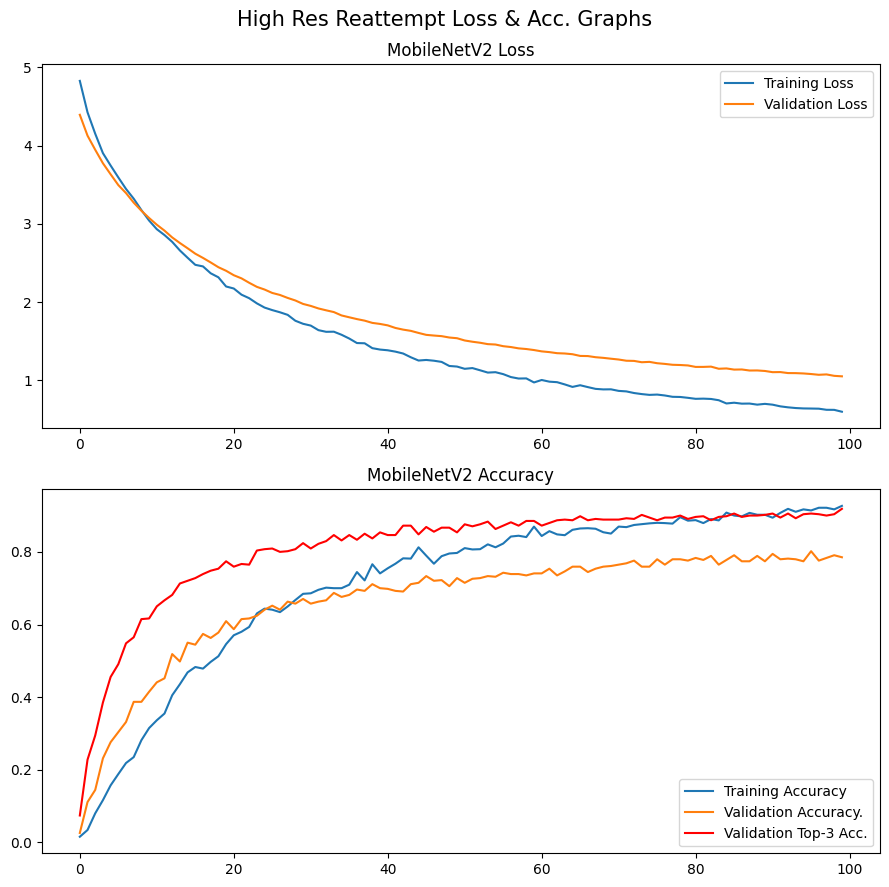

In [ ]:
#previous graph is incorrect
plt.figure(figsize=(9,9))
plt.suptitle("High Res Reattempt Loss & Acc. Graphs",size=15)

plt.subplot(2,1,1)
plt.plot(range(len(high["loss"])),high["loss"],label="Training Loss")
plt.plot(range(len(high["val_loss"])),high["val_loss"],label="Validation Loss")
plt.title("MobileNetV2 Loss")
plt.legend()

plt.subplot(2,1,2)
plt.plot(range(len(high["acc"])),high["acc"],label="Training Accuracy")
plt.plot(range(len(high["val_acc"])),high["val_acc"],label="Validation Accuracy.")
plt.plot(range(len(high["val_top3_acc"])),high["val_top3_acc"],label="Validation Top-3 Acc.",color="red")
plt.title("MobileNetV2 Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

### Test Set

In [ ]:
results = model.evaluate(test_ds, return_dict=True)

print(results)

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step - acc: 0.7831 - loss: 1.0539 - top3_acc: 0.9257
{'acc': 0.7888888716697693, 'loss': 1.04262113571167, 'top3_acc': 0.9203703999519348}


# LowRes (224,224)

## Data Loading

In [ ]:
data_dir = "/content/Data"
os.mkdir(data_dir)

In [ ]:
! unzip -d /content/Data /content/drive/MyDrive/CSAFE_zips/Handwriting_Images_90sorted.zip

In [ ]:
shutil.rmtree("/content/Data/__MACOSX")

In [ ]:
data_dir = "/content/Data/Handwriting_Images"

In [ ]:
IMAGE_SIZE = (224,224)
BATCH_SIZE = 64
INPUT_SHAPE = IMAGE_SIZE + (3,)
NUM_CLASSES = 90

In [ ]:
reload_data2.stratify_split_alt(data_dir)
train_ds,val_ds,test_ds=reload_data2.train_val_test_split(data_dir,
                                                       IMAGE_SIZE=IMAGE_SIZE,
                                                       BATCH_SIZE=BATCH_SIZE)

Found 1350 files belonging to 90 classes.
Found 540 files belonging to 90 classes.
Found 540 files belonging to 90 classes.


## Modelling

In [ ]:
def make_transfer_model(input_shape, num_classes, name):
    backbone = base_model

    backbone.trainable = False

    inputs = layers.Input(input_shape)
    x = keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = backbone(x)
    x = layers.Dropout(0.3)(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.25)(x) #changed to 30% dropout
    outputs = layers.Dense(num_classes, activation=None)(x)

    return keras.Model(inputs, outputs, name=name)

base_model = keras.applications.MobileNetV2(
                        include_top = False,
                        classifier_activation="softmax",
                        weights = "imagenet",
                        input_shape=(IMAGE_SIZE + (3,))
                        )

model = make_transfer_model(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES,
                            name="mobilenet_lowres")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model.summary()

Model: "mobilenet_lowres"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 1280)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 90)             │       115,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,373,274 (9.05 MB)

 Trainable params: 115,290 (450.35 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### epochs

In [ ]:
%%time

epochs = 100

model.compile(
    optimizer= "adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc"),
             keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc")],
    )

history = model.fit(
    train_ds,
    epochs= epochs,
    validation_data= val_ds)

model.save("MobileNetV2_lowres.keras")

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - acc: 0.0108 - loss: 4.7981 - top3_acc: 0.0297 - val_acc: 0.0574 - val_loss: 4.2944 - val_top3_acc: 0.1333
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 381ms/step - acc: 0.0381 - loss: 4.3617 - top3_acc: 0.0965 - val_acc: 0.1185 - val_loss: 4.0455 - val_top3_acc: 0.2389
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 398ms/step - acc: 0.0819 - loss: 4.0571 - top3_acc: 0.1781 - val_acc: 0.1815 - val_loss: 3.8624 - val_top3_acc: 0.3611
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 370ms/step - acc: 0.1363 - loss: 3.8030 - top3_acc: 0.2721 - val_acc: 0.2296 - val_loss: 3.6930 - val_top3_acc: 0.4352
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 393ms/step - acc: 0.1824 - loss: 3.6232 - top3_acc: 0.3174 - val_acc: 0.2815 - val_loss: 3.5440 - val_top3_acc: 0.4741
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 380ms/step - acc: 0.2088 - loss: 3.4619 - top3_acc: 0.3877 - val_acc: 0.2963 - val_loss: 3.4279 - val_top3_acc: 0.4815
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━

In [ ]:
#save metrics
lossacc = pd.DataFrame(history.history)
lossacc.to_csv("lowres_lossacc.csv")

### Visualization

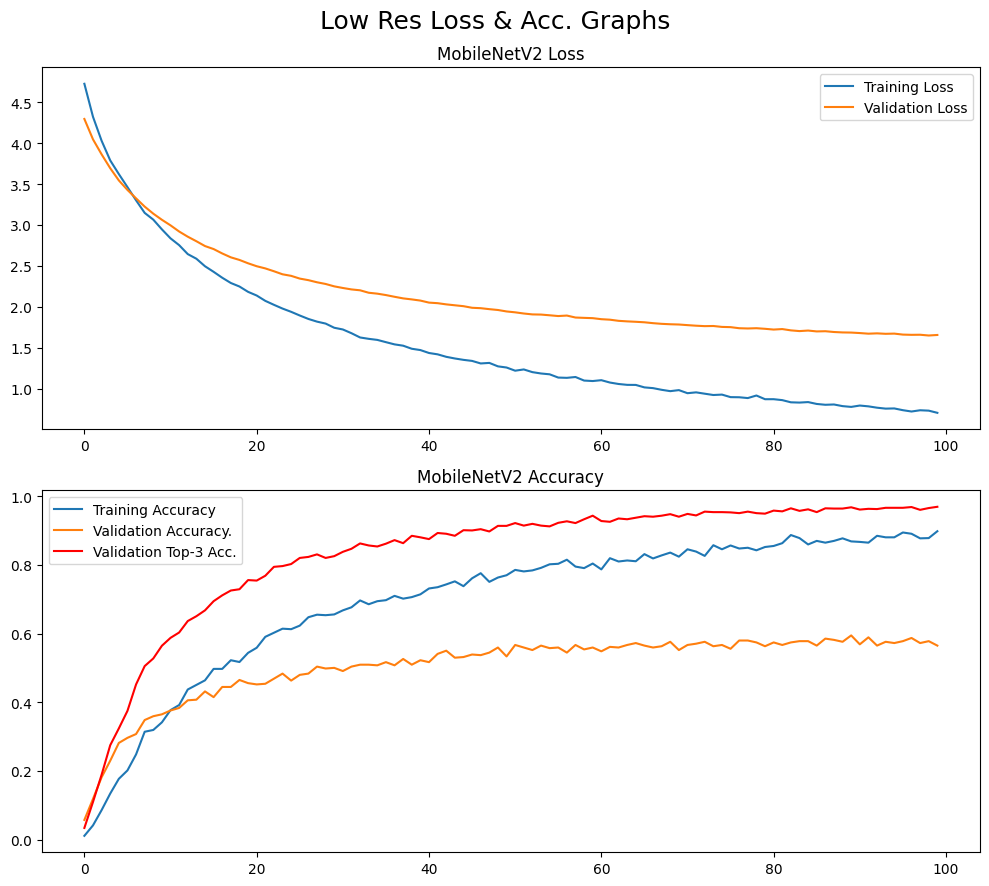

In [ ]:
plt.figure(figsize=(10,9))
plt.suptitle("Low Res Loss & Acc. Graphs",size=18)

plt.subplot(2,1,1)
plt.plot(range(len(history.history["loss"])),history.history["loss"],label="Training Loss")
plt.plot(range(len(history.history["val_loss"])),history.history["val_loss"],label="Validation Loss")
plt.title("MobileNetV2 Loss")
plt.legend()

plt.subplot(2,1,2)
plt.plot(range(len(history.history["acc"])),history.history["acc"],label="Training Accuracy")
plt.plot(range(len(history.history["val_acc"])),history.history["val_acc"],label="Validation Accuracy.")
plt.plot(range(len(history.history["top3_acc"])),history.history["top3_acc"],label="Validation Top-3 Acc.",color="red")
plt.title("MobileNetV2 Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

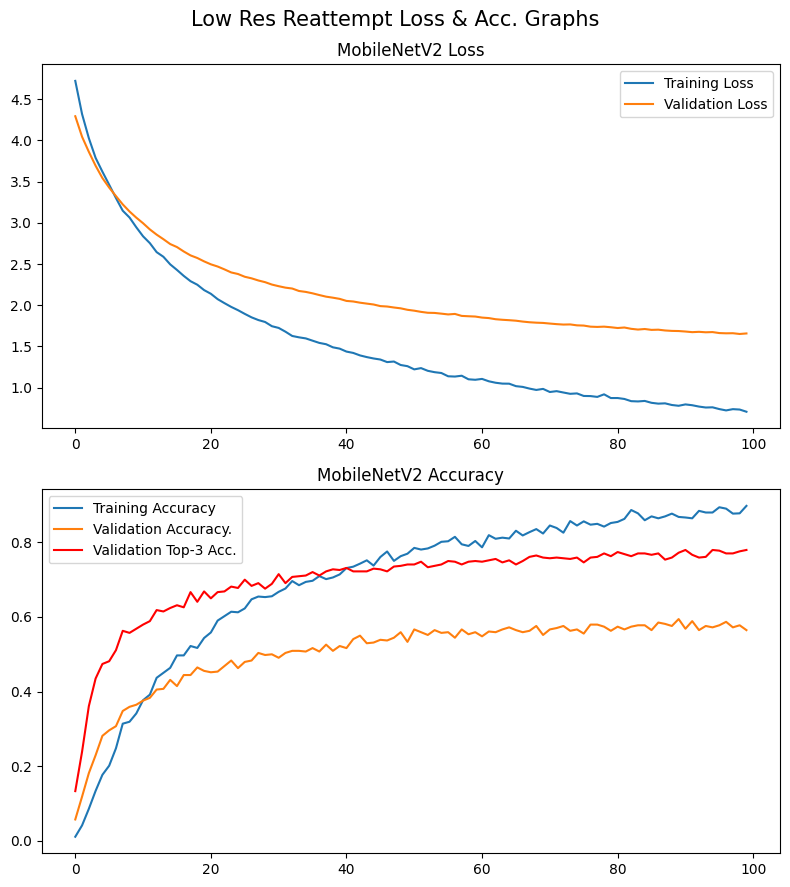

In [ ]:
#previous graph is incorrect
plt.figure(figsize=(8,9))
plt.suptitle("Low Res Reattempt Loss & Acc. Graphs",size=15)

plt.subplot(2,1,1)
plt.plot(range(len(low["loss"])),low["loss"],label="Training Loss")
plt.plot(range(len(low["val_loss"])),low["val_loss"],label="Validation Loss")
plt.title("MobileNetV2 Loss")
plt.legend()

plt.subplot(2,1,2)
plt.plot(range(len(low["acc"])),low["acc"],label="Training Accuracy")
plt.plot(range(len(low["val_acc"])),low["val_acc"],label="Validation Accuracy.")
plt.plot(range(len(low["val_top3_acc"])),low["val_top3_acc"],label="Validation Top-3 Acc.",color="red")
plt.title("MobileNetV2 Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

### Test Set

In [ ]:
results = model.evaluate(test_ds, return_dict=True)

print(results)

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 247ms/step - acc: 0.5549 - loss: 1.6797 - top3_acc: 0.7664
{'acc': 0.5777778029441833, 'loss': 1.6659618616104126, 'top3_acc': 0.7685185074806213}


# MedRes (384,384)

## Data Loading

In [ ]:
IMAGE_SIZE = (384,384)
BATCH_SIZE = 64
INPUT_SHAPE = IMAGE_SIZE + (3,)
NUM_CLASSES = 90

In [ ]:
reload_data2.stratify_split_alt(data_dir)
train_ds,val_ds,test_ds=reload_data2.train_val_test_split(data_dir,
                                                       IMAGE_SIZE=IMAGE_SIZE,
                                                       BATCH_SIZE=BATCH_SIZE)

Found 1350 files belonging to 90 classes.
Found 540 files belonging to 90 classes.
Found 540 files belonging to 90 classes.


## Modelling

In [ ]:
model = make_transfer_model(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES,
                            name="mobilenet_medres")

/tmp/ipykernel_2627/3188229622.py:18: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


In [ ]:
model.summary()

Model: "mobilenet_medres"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 12, 12, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 1280)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 90)             │       115,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,373,274 (9.05 MB)

 Trainable params: 115,290 (450.35 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### epochs

In [ ]:
%%time

epochs = 100

model.compile(
    optimizer= "adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc"),
             keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc")],
    )

history = model.fit(
    train_ds,
    epochs= epochs,
    validation_data= val_ds)

model.save("MobileNetV2_medres.keras")

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - acc: 0.0160 - loss: 4.9573 - top3_acc: 0.0404 - val_acc: 0.0481 - val_loss: 4.3382 - val_top3_acc: 0.1222
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 426ms/step - acc: 0.0294 - loss: 4.4628 - top3_acc: 0.0717 - val_acc: 0.1278 - val_loss: 4.0407 - val_top3_acc: 0.2593
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 397ms/step - acc: 0.0914 - loss: 4.0883 - top3_acc: 0.1824 - val_acc: 0.1722 - val_loss: 3.8522 - val_top3_acc: 0.3574
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 410ms/step - acc: 0.1227 - loss: 3.9120 - top3_acc: 0.2399 - val_acc: 0.2315 - val_loss: 3.6854 - val_top3_acc: 0.4407
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 418ms/step - acc: 0.1508 - loss: 3.7030 - top3_acc: 0.3161 - val_acc: 0.2759 - val_loss: 3.5477 - val_top3_acc: 0.4630
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 402ms/step - acc: 0.1866 - loss: 3.5476 - top3_acc: 0.3521 - val_acc: 0.3241 - val_loss: 3.4029 - val_top3_acc: 0.5315
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━

In [ ]:
#save metrics
lossacc = pd.DataFrame(history.history)
lossacc.to_csv("medres_lossacc.csv")

### Visualization

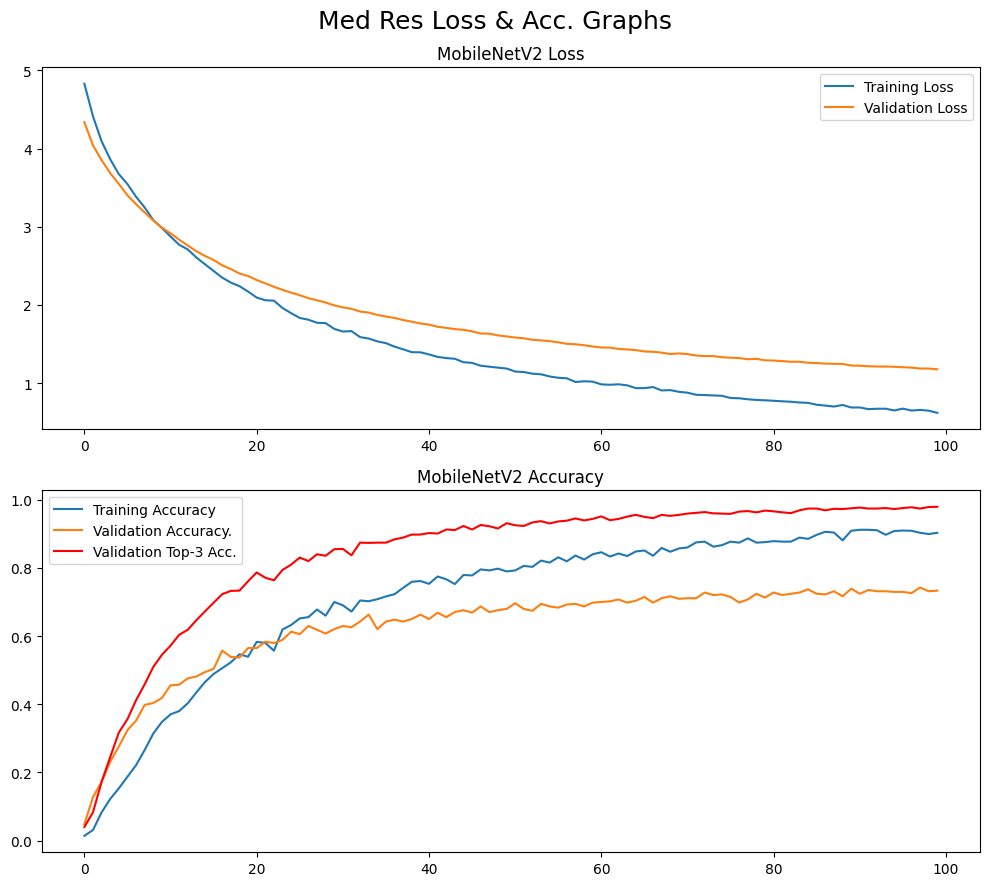

In [ ]:
plt.figure(figsize=(9,9))
plt.suptitle("Med Res Loss & Acc. Graphs",size=18)

plt.subplot(2,1,1)
plt.plot(range(len(history.history["loss"])),history.history["loss"],label="Training Loss")
plt.plot(range(len(history.history["val_loss"])),history.history["val_loss"],label="Validation Loss")
plt.title("MobileNetV2 Loss")
plt.legend()

plt.subplot(2,1,2)
plt.plot(range(len(history.history["acc"])),history.history["acc"],label="Training Accuracy")
plt.plot(range(len(history.history["val_acc"])),history.history["val_acc"],label="Validation Accuracy.")
plt.plot(range(len(history.history["top3_acc"])),history.history["top3_acc"],label="Validation Top-3 Acc.",color="red")
plt.title("MobileNetV2 Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

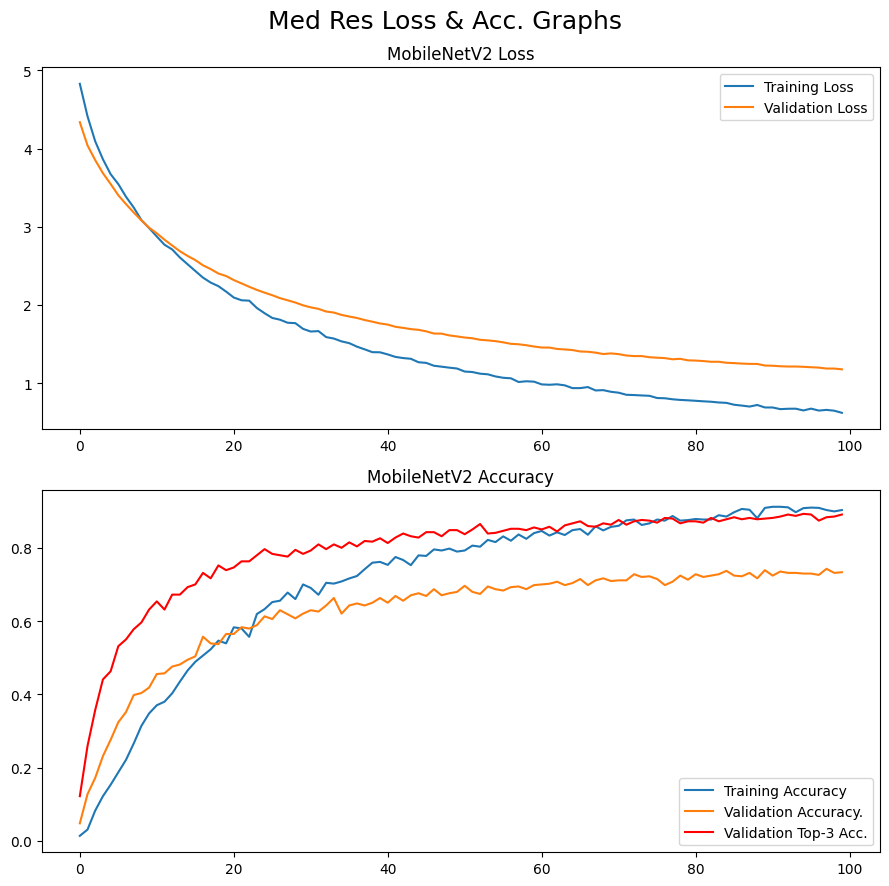

In [ ]:
#previous graph is incorrect
plt.figure(figsize=(9,9))
plt.suptitle("Med Res Loss & Acc. Graphs",size=18)

plt.subplot(2,1,1)
plt.plot(range(len(med["loss"])),med["loss"],label="Training Loss")
plt.plot(range(len(med["val_loss"])),med["val_loss"],label="Validation Loss")
plt.title("MobileNetV2 Loss")
plt.legend()

plt.subplot(2,1,2)
plt.plot(range(len(med["acc"])),med["acc"],label="Training Accuracy")
plt.plot(range(len(med["val_acc"])),med["val_acc"],label="Validation Accuracy.")
plt.plot(range(len(med["val_top3_acc"])),med["val_top3_acc"],label="Validation Top-3 Acc.",color="red")
plt.title("MobileNetV2 Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

### Test Set

In [ ]:
results = model.evaluate(test_ds, return_dict=True)

print(results)

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 252ms/step - acc: 0.7261 - loss: 1.2199 - top3_acc: 0.8708
{'acc': 0.7370370626449585, 'loss': 1.1902012825012207, 'top3_acc': 0.8740741014480591}


# Comparison

In [ ]:
low=pd.read_csv("/content/lowres_lossacc.csv")
high=pd.read_csv("/content/highres2_lossacc.csv")
med=pd.read_csv("/content/medres_lossacc.csv")

In [ ]:
low.head()

,Unnamed: 0,acc,loss,top3_acc,val_acc,val_loss,val_top3_acc
0,0,0.011111,4.723909,0.034074,0.057407,4.294394,0.133333
1,1,0.041481,4.320979,0.109630,0.118519,4.045527,0.238889
2,2,0.085926,4.028414,0.188889,0.181481,3.862368,0.361111
3,3,0.134074,3.788563,0.274815,0.229630,3.692966,0.435185
4,4,0.177037,3.621409,0.323704,0.281481,3.544019,0.474074


In [ ]:
high.head()

,Unnamed: 0,acc,loss,top3_acc,val_acc,val_loss,val_top3_acc
0,0,0.015556,4.826752,0.040741,0.025926,4.393490,0.074074
1,1,0.034074,4.424979,0.105185,0.111111,4.127130,0.227778
2,2,0.080000,4.151652,0.177778,0.144444,3.946738,0.294444
3,3,0.116296,3.903849,0.243704,0.231481,3.774541,0.385185
4,4,0.157037,3.745630,0.299259,0.275926,3.633822,0.455556


In [ ]:
help(plt.cm)

Help on module matplotlib.cm in matplotlib:

NAME
    matplotlib.cm - Builtin colormaps, colormap handling utilities, and the `ScalarMappable` mixin.

DESCRIPTION
    .. seealso::

      :doc:`/gallery/color/colormap_reference` for a list of builtin colormaps.

      :ref:`colormap-manipulation` for examples of how to make
      colormaps.

      :ref:`colormaps` an in-depth discussion of choosing
      colormaps.

      :ref:`colormapnorms` for more details about data normalization.

CLASSES
    collections.abc.Mapping(collections.abc.Collection)
        ColormapRegistry

    class ColormapRegistry(collections.abc.Mapping)
     |  ColormapRegistry(cmaps)
     |
     |  Container for colormaps that are known to Matplotlib by name.
     |
     |  The universal registry instance is `matplotlib.colormaps`. There should be
     |  no need for users to instantiate `.ColormapRegistry` themselves.
     |
     |  Read access uses a dict-like interface mapping names to `.Colormap`\s::
     |
  

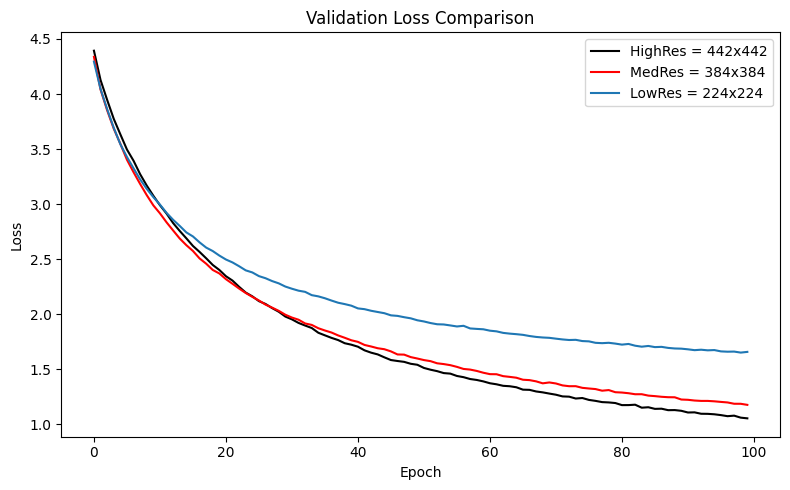

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(len(high["loss"])),high["val_loss"],label="HighRes = 442x442",c="black")
plt.plot(range(len(med["loss"])),med["val_loss"],label="MedRes = 384x384",c="red")
plt.plot(range(len(low["loss"])),low["val_loss"],label="LowRes = 224x224")
plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

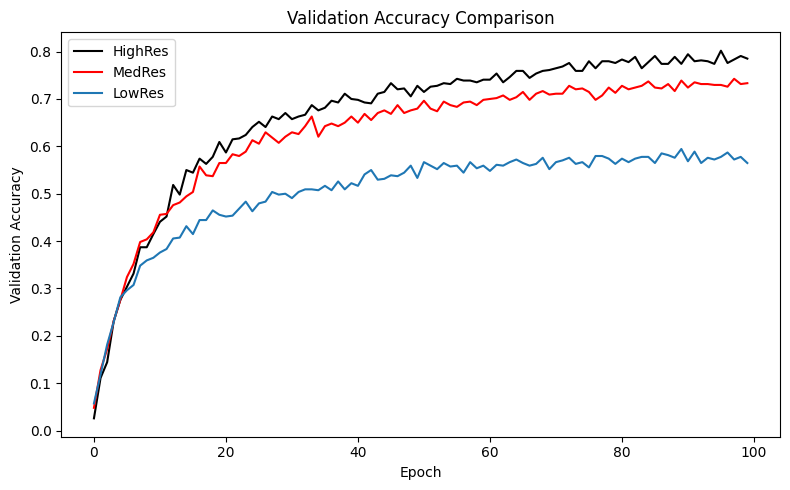

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(len(high["val_acc"])),high["val_acc"],label="HighRes",c="black",
       #  alpha=0.5
         )
plt.plot(range(len(med["val_acc"])),med["val_acc"],label="MedRes",c="red",
        # alpha=0.5
         )
plt.plot(range(len(low["val_acc"])),low["val_acc"],label="LowRes",
         #linestyle=":",linewidth=4
         )
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()